# QSVM — Step-4 diagnostics: composition, dimension, anchors, residuals

Companion to *Comments on the Latest Quantum-Kernel SVM Experiments* (S. Rayan, 17 Aug
2026), Section 7, items 1-4, 8 and 9. Item 6 (pooled-feature duplicates) was already done
in the Step-3 notebook and is not repeated here. Item 5 (PCA/dispersion ablation) is
folded into Experiment 2 below, without the PCA-confound the original ablation had. Item
7 (composition-preserving redocking) needs a molecular docking simulator and is out of
scope for this notebook. Item 10 (selection-aware null test) is deferred until these
results identify which comparisons are worth calibrating.

**Everything here is classical-only.** Every comparison in this notebook involves at
least one representation with more than 10 features (`comp_freq_20`, `full_45`,
`residual_50`, the two 15-feature anchor variants), and the exact quantum kernel needs
one qubit per feature — `full_45` alone would need a 2^45-entry statevector, which is not
simulable. This mirrors exactly how the original manuscript treated one-hot encoding and
the untruncated z-value table as "classical only".

**Design: paired comparison, not representation-selection.** Unlike the Step-3 notebook
(where the representation was chosen *inside* the inner loop), each representation here
runs its **own** standard nested CV — only hyperparameters are chosen internally — and
representations are compared afterwards with the same paired-uncertainty machinery from
Step 5 (Nadeau-Bengio interval, group bootstrap). That is the right tool for "does A beat
B on identical folds", which is what these diagnostics ask.

**Data note.** `zscaled_5_45.csv` (the 45-feature unpooled table) is built from a
slightly different z-scale lookup table than `zscale_dataset.csv` (max per-entry
difference ≈0.0076 — the same discrepancy found between `zscale_dataset.csv` and
`moments_order1_z5.csv` earlier). To keep "mean" and "full" internally consistent, `mean_z`
in this notebook is derived by **averaging `zscaled_5_45.csv` over its 9 positions**,
not read from `zscale_dataset.csv`.

## 1. Configuration and imports

In [48]:
import os
import json
import time
import itertools
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, StratifiedGroupKFold
from sklearn.svm import SVC
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import (balanced_accuracy_score, accuracy_score, matthews_corrcoef,
                             mean_absolute_error, mean_squared_error)
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel, polynomial_kernel

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_SPLITS_OUTER, N_REPEATS_OUTER, N_SPLITS_INNER = 5, 20, 4

CLASSICAL_GRIDS = {
    'linear': {'C': [0.1, 1, 10]},
    'rbf':    {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1, 1]},
    'poly':   {'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 0.1, 1], 'coef0': [0.0, 1.0]},
}
REGRESSION_GRIDS = {
    'linear': {'alpha': [0.01, 0.1, 1, 10]},
    'rbf':    {'alpha': [0.01, 0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1, 1]},
}
MODELS = ['linear', 'rbf', 'poly']   # classical kernel families used throughout

OUTDIR = 'results_diagnostics'
os.makedirs(OUTDIR, exist_ok=True)
print(f'outer {N_SPLITS_OUTER}x{N_REPEATS_OUTER} = {N_SPLITS_OUTER*N_REPEATS_OUTER} folds, inner {N_SPLITS_INNER}')

outer 5x20 = 100 folds, inner 4


## 2. Data, sequences, groups, and the base 45-feature table

In [49]:
_lab = pd.read_excel('Docking_high_low_energy_labels.xlsx', sheet_name='Results')
_lab = _lab.dropna(subset=['Sequence Epitope)']).reset_index(drop=True)
sequences = _lab['Sequence Epitope)'].astype(str).str.strip().tolist()
y = (_lab['Otsu Class theshold -77.8'] == 'Strong').astype(int).values
E = _lab['Binding Energy '].values  # continuous docking energy, for Experiment 8

full45 = pd.read_csv('zscaled_5_45.csv', index_col=0).values  # (80, 45): z_p_k, p=1..9, k=1..5
assert full45.shape == (len(y), 45)

print(f'{len(y)} peptides, class balance {np.bincount(y)}, '
      f'binding energy range [{E.min():.1f}, {E.max():.1f}]')

80 peptides, class balance [42 38], binding energy range [-108.5, -48.5]


/home/luispabloelchido/miniconda3/envs/QML/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [50]:
# sequence-redundancy groups -- identical construction to the Step-3 notebook
K_SHARED, IDENTITY_THRESH = 5, 7 / 9


def similarity_edges(sequences, k_shared=K_SHARED, identity_thresh=IDENTITY_THRESH):
    n, L = len(sequences), len(sequences[0])
    kmers = [{s[i:i + k_shared] for i in range(L - k_shared + 1)} for s in sequences]
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            shared = bool(kmers[i] & kmers[j])
            identity = sum(a == b for a, b in zip(sequences[i], sequences[j])) / L
            if shared or identity >= identity_thresh:
                edges.append((i, j))
    return edges


def build_groups_unionfind(n, edges):
    parent = list(range(n))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    for i, j in edges:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj
    raw = [find(i) for i in range(n)]
    remap = {g: k for k, g in enumerate(sorted(set(raw)))}
    return np.array([remap[g] for g in raw])


n_pep = len(sequences)
edges = similarity_edges(sequences)
groups = build_groups_unionfind(n_pep, edges)

adj = coo_matrix((np.ones(len(edges)),
                  (np.array([e[0] for e in edges]), np.array([e[1] for e in edges]))),
                 shape=(n_pep, n_pep))
n_cc, cc_labels = connected_components(adj, directed=False)
assert len(set(zip(groups, cc_labels))) == len(set(groups)) == len(set(cc_labels))
print(f'{len(np.unique(groups))} groups (verified against scipy connected components), '
      f'{pd.Series(groups).value_counts().eq(1).sum()} singletons')

43 groups (verified against scipy connected components), 25 singletons


## 3. Derived representations

All of these are deterministic, per-peptide computations (or, for the two fold-safe
transforms, computations that only ever look at the fold's own training rows) — none of
them use information from other peptides in a way that could leak across a split.

| name | dims | what it is | used in |
|---|---|---|---|
| `mean_z` | 5 | mean of the 5 z-scales over the 9 positions (derived from `full45`, not `zscale_dataset.csv` — see the note above) | 1, 2, 3, 4, 9 |
| `comp_freq_20` | 20 | frequency of each of the 20 canonical amino acids in the peptide | 1 |
| `rand_proj_5` | 5 | `full45`, standardised with TRAIN-fold statistics, times a **fixed** random 45x5 matrix (data- and label-independent) | 2 |
| `pca_5` | 5 | `full45`, standardised and PCA-reduced to 5 dims, both fitted **within the training fold only** | 2 |
| `full45` | 45 | the raw unpooled table (no reduction at all) | 2, 9 |
| `anchor_raw_15` | 15 | mean of positions {1,3,4,5,6,7,8} (excludes 2 and 9, no double-counting) + raw position-2 vector + raw position-9 vector | 3a |
| `anchor_residual_15` | 15 | `mean_z` (all 9 positions) + (position-2 minus `mean_z`) + (position-9 minus `mean_z`) | 3b |
| `residual_50` | 50 | `mean_z` (5) concatenated with `R_ip = z(a_ip) - z-bar_i` for all 9 positions (45) — Steve's Equation 3 | 4 |

In [51]:
def mean_from_full45(X45, exclude_positions=()):
    """Mean z-scale over the 9 positions, optionally excluding some (0-indexed positions)."""
    keep = [p for p in range(9) if p not in exclude_positions]
    out = np.zeros((X45.shape[0], 5))
    for k in range(5):
        cols = [p * 5 + k for p in keep]
        out[:, k] = X45[:, cols].mean(axis=1)
    return out


mean_z = mean_from_full45(full45)                       # z_i, Eq 1/3 in Steve's note
mean_z7 = mean_from_full45(full45, exclude_positions=(1, 8))  # excludes position 2 (idx1), position 9 (idx8)
pos2, pos9 = full45[:, 5:10], full45[:, 40:45]

AAS = sorted(set(''.join(sequences)))
comp_freq_20 = np.zeros((n_pep, len(AAS)))
for i, s in enumerate(sequences):
    for a in s:
        comp_freq_20[i, AAS.index(a)] += 1
comp_freq_20 /= len(sequences[0])

anchor_raw_15 = np.hstack([mean_z7, pos2, pos9])
anchor_residual_15 = np.hstack([mean_z, pos2 - mean_z, pos9 - mean_z])

mean_broadcast = np.zeros((n_pep, 45))
for p in range(9):
    mean_broadcast[:, p * 5:(p * 5 + 5)] = mean_z
R_i = full45 - mean_broadcast                            # R_ip, Eq 3
residual_50 = np.hstack([mean_z, R_i])                   # (z_i, R_i), Eq 3

resid_check = np.abs(np.stack([R_i[:, [p * 5 + k for p in range(9)]].sum(axis=1)
                               for k in range(5)])).max()
print(f'sanity: max |sum of residuals over 9 positions| = {resid_check:.2e} (should be ~0)')

for name, X in [('mean_z', mean_z), ('comp_freq_20', comp_freq_20), ('full45', full45),
                 ('anchor_raw_15', anchor_raw_15), ('anchor_residual_15', anchor_residual_15),
                 ('residual_50', residual_50)]:
    assert np.isfinite(X).all(), name
    print(f'  {name:20s} {X.shape}')


def make_random_projection(n_features_in, n_out=5, seed=2026):
    """A FIXED matrix, generated once, never refit -- the non-biological, non-learned control."""
    rng = np.random.default_rng(seed)
    return rng.normal(size=(n_features_in, n_out)) / np.sqrt(n_features_in)


RAND_R = make_random_projection(45, 5)
RAND_R_1= make_random_projection(45, 5,2000)
RAND_R_2 = make_random_projection(45, 5,2098)
RAND_R_3 = make_random_projection(45, 5,2572)
RAND_R_4 = make_random_projection(45, 5,23)
RAND_R_5 = make_random_projection(45, 5,42)

sanity: max |sum of residuals over 9 positions| = 4.66e-15 (should be ~0)
  mean_z               (80, 5)
  comp_freq_20         (80, 20)
  full45               (80, 45)
  anchor_raw_15        (80, 15)
  anchor_residual_15   (80, 15)
  residual_50          (80, 50)


## 4. Nested-CV machinery

Same discipline as Step 3: every learned transform is fit only on the training part of
its fold. Two representations need a **fold-safe transform** rather than a static array —
`rand_proj_5` (standardise on train, then apply the fixed matrix) and `pca_5` (standardise
*and* fit PCA on train only) — implemented as callables with the same signature as the
static-array path.

In [52]:
def fit_scale(X_train, X_test):
    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    scaler.fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)


def transform_random_projection(X_train, X_test, R):
    mu, sd = X_train.mean(0), X_train.std(0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X_train - mu) / sd) @ R, ((X_test - mu) / sd) @ R


def transform_pca(X_train, X_test, n_components=5):
    scaler = StandardScaler().fit(X_train)
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED).fit(scaler.transform(X_train))
    return pca.transform(scaler.transform(X_train)), pca.transform(scaler.transform(X_test))


def _transform(rep, tr_idx, te_idx):
    """rep is either a static (N,d) array, or a callable(tr_idx, te_idx) -> (Xtr, Xte)."""
    if callable(rep):
        return rep(tr_idx, te_idx)
    Xtr, Xte = fit_scale(rep[tr_idx], rep[te_idx])
    return Xtr, Xte


REPS = {
    'mean_z': mean_z, 'comp_freq_20': comp_freq_20, 'full45': full45,
    'anchor_raw_15': anchor_raw_15, 'anchor_residual_15': anchor_residual_15,
    'residual_50': residual_50,
    'rand_proj_5': lambda tr, te: transform_random_projection(
        full45[tr], full45[te], RAND_R),
    'rand_1': lambda tr, te: transform_random_projection(
    full45[tr], full45[te], RAND_R_1
    ),

    'rand_2': lambda tr, te: transform_random_projection(
        full45[tr], full45[te], RAND_R_2
    ),

    'rand_3': lambda tr, te: transform_random_projection(
        full45[tr], full45[te], RAND_R_3
    ),

    'rand_4': lambda tr, te: transform_random_projection(
        full45[tr], full45[te], RAND_R_4
    ),

    'rand_5': lambda tr, te: transform_random_projection(
        full45[tr], full45[te], RAND_R_5
    ),
    'pca_5': lambda tr, te: transform_pca(full45[tr], full45[te], n_components=5),
}

In [53]:
def make_outer_splits(y, groups=None, n_splits=N_SPLITS_OUTER, n_repeats=N_REPEATS_OUTER,
                      random_state=RANDOM_SEED):
    if groups is None:
        return list(RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                            random_state=random_state).split(np.zeros(len(y)), y))
    splits = []
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state + r)
        splits.extend(sgkf.split(np.zeros(len(y)), y, groups))
    return splits


def _inner_splits(y_tr, groups_tr, fold_i):
    if groups_tr is None:
        return list(StratifiedKFold(n_splits=N_SPLITS_INNER, shuffle=True,
                                    random_state=RANDOM_SEED + fold_i).split(np.zeros(len(y_tr)), y_tr))
    return list(StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True,
                                     random_state=RANDOM_SEED + fold_i)
                .split(np.zeros(len(y_tr)), y_tr, groups_tr))


def _param_combinations(grid):
    keys = list(grid)
    return [dict(zip(keys, vals)) for vals in itertools.product(*(grid[k] for k in keys))]


def _resolve_gamma(gamma, Xs):
    if gamma == 'scale':
        return 1.0 / (Xs.shape[1] * Xs.var()) if Xs.var() > 0 else 1.0
    return gamma


def _fit_svc(kernel_name, Xtr, ytr, params):
    gamma = _resolve_gamma(params.get('gamma', 'scale'), Xtr)
    if kernel_name == 'linear':
        clf = SVC(kernel='linear', C=params['C'])
    elif kernel_name == 'rbf':
        clf = SVC(kernel='rbf', C=params['C'], gamma=gamma)
    else:
        clf = SVC(kernel='poly', C=params['C'], degree=params['degree'], gamma=gamma, coef0=params['coef0'])
    return clf.fit(Xtr, ytr)


def _build_gram(kernel_name, Xa, Xb, params, Xtr):
    gamma = _resolve_gamma(params.get('gamma', 'scale'), Xtr)
    if kernel_name == 'linear':
        return linear_kernel(Xa, Xb)
    if kernel_name == 'rbf':
        return rbf_kernel(Xa, Xb, gamma=gamma)
    return polynomial_kernel(Xa, Xb, degree=params['degree'], gamma=gamma, coef0=params['coef0'])


def kernel_diagnostics(K, y_pm1):
    m = len(y_pm1)
    S = y_pm1 @ K @ y_pm1 - np.trace(K)
    Q = np.sum(K ** 2) - np.sum(np.diag(K) ** 2)
    kta = (m + S) / (m * np.sqrt(m + Q))
    H = np.eye(m) - np.ones((m, m)) / m
    Kc, yyTc = H @ K @ H, H @ np.outer(y_pm1, y_pm1).astype(float) @ H
    cka = np.sum(Kc * yyTc) / (np.linalg.norm(Kc) * np.linalg.norm(yyTc) + 1e-15)
    eig = np.clip(np.linalg.eigvalsh((K + K.T) / 2), 0, None)
    eff_rank = (eig.sum() ** 2) / (np.sum(eig ** 2) + 1e-15)
    return kta, cka, eff_rank


def nested_cv_classical(rep, y, kernel_name, groups=None, n_repeats_outer=N_REPEATS_OUTER, verbose=False):
    """Standard nested CV for ONE fixed representation -- no representation selection."""
    combos = _param_combinations(CLASSICAL_GRIDS[kernel_name])
    outer = make_outer_splits(y, groups, n_repeats=n_repeats_outer)
    rows, predictions = [], {}

    for fold_i, (tr_idx, te_idx) in enumerate(outer):
        y_tr, y_te = y[tr_idx], y[te_idx]
        inner = _inner_splits(y_tr, None if groups is None else groups[tr_idx], fold_i)

        inner_scores = {}
        for in_tr, in_val in inner:
            abs_tr, abs_val = tr_idx[in_tr], tr_idx[in_val]
            Xi_tr, Xi_val = _transform(rep, abs_tr, abs_val)
            for ci, params in enumerate(combos):
                clf = _fit_svc(kernel_name, Xi_tr, y[abs_tr], params)
                s = balanced_accuracy_score(y[abs_val], clf.predict(Xi_val))
                inner_scores.setdefault(ci, []).append(s)

        best_ci = max(inner_scores, key=lambda k: np.mean(inner_scores[k]))
        best_params = combos[best_ci]

        Xtr, Xte = _transform(rep, tr_idx, te_idx)
        clf = _fit_svc(kernel_name, Xtr, y_tr, best_params)
        y_pred = clf.predict(Xte)
        K_tr = _build_gram(kernel_name, Xtr, Xtr, best_params, Xtr)
        kta, cka, eff = kernel_diagnostics(K_tr, np.where(y_tr == 1, 1, -1))

        row = {'fold': fold_i, 'inner_score': float(np.mean(inner_scores[best_ci])),
               'accuracy': accuracy_score(y_te, y_pred),
               'balanced_accuracy': balanced_accuracy_score(y_te, y_pred),
               'mcc': matthews_corrcoef(y_te, y_pred) if len(set(y_pred)) > 1 else 0.0,
               'kta': kta, 'cka': cka, 'effective_rank': eff,
               'n_train': len(tr_idx), 'n_test': len(te_idx)}
        row.update({f'best_{k}': v for k, v in best_params.items()})
        rows.append(row)
        predictions[fold_i] = {'test_idx': te_idx.tolist(), 'y_true': y_te.tolist(), 'y_pred': y_pred.tolist()}
    return pd.DataFrame(rows), predictions

In [54]:
def per_fold_metrics(predictions):
    accs, baccs, mccs = [], [], []
    for fold_i in sorted(predictions, key=int):
        yt = np.asarray(predictions[fold_i]['y_true'])
        yp = np.asarray(predictions[fold_i]['y_pred'])
        accs.append(accuracy_score(yt, yp))
        baccs.append(balanced_accuracy_score(yt, yp))
        mccs.append(matthews_corrcoef(yt, yp) if len(set(yp)) > 1 else 0.0)
    return {'accuracy': np.array(accs), 'balanced_accuracy': np.array(baccs), 'mcc': np.array(mccs)}


def nadeau_bengio_ci(diff, n_train, n_test, alpha=0.05):
    diff = np.asarray(diff, dtype=float)
    J = len(diff)
    var = diff.var(ddof=1)
    se = np.sqrt(var * (1.0 / J + n_test / n_train))
    t = stats.t.ppf(1 - alpha / 2, df=J - 1)
    mean = diff.mean()
    t_stat = mean / se if se > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t_stat), df=J - 1)) if np.isfinite(t_stat) else np.nan
    return float(mean), float(mean - t * se), float(mean + t * se), float(p)


def _peptide_tallies(predictions, n_samples):
    n_pred, n_correct = np.zeros(n_samples), np.zeros(n_samples)
    for fold_i in sorted(predictions, key=int):
        idx = np.asarray(predictions[fold_i]['test_idx'])
        yt, yp = np.asarray(predictions[fold_i]['y_true']), np.asarray(predictions[fold_i]['y_pred'])
        n_pred[idx] += 1
        n_correct[idx] += (yt == yp)
    return n_pred, n_correct


def bootstrap_group_ci(pred_a, pred_b, groups, y, n_boot=10000, seed=RANDOM_SEED):
    n = len(y)
    na, ca = _peptide_tallies(pred_a, n)
    nb, cb = _peptide_tallies(pred_b, n)
    uniq = np.unique(groups)
    members = [np.where(groups == g)[0] for g in uniq]
    pos = (y == 1)

    def bacc(n_pred, n_corr, idx):
        p, q = idx[pos[idx]], idx[~pos[idx]]
        tpr = n_corr[p].sum() / n_pred[p].sum() if n_pred[p].sum() > 0 else np.nan
        tnr = n_corr[q].sum() / n_pred[q].sum() if n_pred[q].sum() > 0 else np.nan
        return 0.5 * (tpr + tnr)

    rng = np.random.default_rng(seed)
    all_idx = np.arange(n)
    observed = bacc(na, ca, all_idx) - bacc(nb, cb, all_idx)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.concatenate([members[k] for k in rng.integers(0, len(uniq), size=len(uniq))])
        boots[b] = bacc(na, ca, idx) - bacc(nb, cb, idx)
    boots = boots[np.isfinite(boots)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(observed), float(lo), float(hi)


def paired_report(res_a, pred_a, res_b, pred_b, groups, y, label_a, label_b):
    ma, mb = per_fold_metrics(pred_a), per_fold_metrics(pred_b)
    d = ma['balanced_accuracy'] - mb['balanced_accuracy']
    n_tr, n_te = res_a['n_train'].mean(), res_a['n_test'].mean()
    m_n, lo_n, hi_n, p_n = nadeau_bengio_ci(d, n_tr, n_te)
    m_g, lo_g, hi_g = bootstrap_group_ci(pred_a, pred_b, groups, y)
    return {'comparison': f'{label_a} vs {label_b}',
            f'BA_{label_a}': ma['balanced_accuracy'].mean(), f'BA_{label_b}': mb['balanced_accuracy'].mean(),
            'mean_diff': m_n, 'nadeau_bengio_lo': lo_n, 'nadeau_bengio_hi': hi_n,
            'nadeau_bengio_excl_0': (lo_n > 0) or (hi_n < 0),
            'group_boot_diff': m_g, 'group_boot_lo': lo_g, 'group_boot_hi': hi_g,
            'group_boot_excl_0': (lo_g > 0) or (hi_g < 0)}


def run_representation(name, rep, models=MODELS, groups=groups, n_repeats_outer=N_REPEATS_OUTER):
    """Run all classical kernel families for one representation; return {model: (res, preds)}."""
    out = {}
    for kn in models:
        res, preds = nested_cv_classical(rep, y, kn, groups=groups, n_repeats_outer=n_repeats_outer)
        out[kn] = (res, preds)
    return out


def summarize(results_by_rep):
    rows = []
    for rep_name, by_model in results_by_rep.items():
        for kn, (res, preds) in by_model.items():
            rows.append({'representation': rep_name, 'model': kn,
                         'balanced_accuracy': res['balanced_accuracy'].mean(),
                         'accuracy': res['accuracy'].mean(), 'mcc': res['mcc'].mean()})
    return pd.DataFrame(rows).pivot(index='representation', columns='model', values='balanced_accuracy')

## 5. Experiment 1 — composition control

**Theory.** Steve's own Eq. 1 shows `mean_z` is a linear projection of the peptide's
amino-acid composition: `z-bar = sum_a f_a * z(a)`. So the question is whether the
continuous z-scale *values* add anything over just knowing which amino acids are present
and how often. `comp_freq_20` is the raw 20-dimensional frequency vector. If it performs
as well as `mean_z`, the z-scale's physicochemical content is redundant with raw
composition. If `mean_z` clearly wins, the specific numeric values are adding real
information.

In [57]:
t0 = time.time()
res_exp1 = {'mean_z': run_representation('mean_z', REPS['mean_z']),
           'comp_freq_20': run_representation('comp_freq_20', REPS['comp_freq_20'])}
print(f'Experiment 1: {time.time()-t0:.0f}s')
tab1 = summarize(res_exp1)
tab1.to_csv(f'{OUTDIR}/exp1_composition.csv')
display(tab1)

comp1 = pd.DataFrame([paired_report(res_exp1['mean_z'][kn][0], res_exp1['mean_z'][kn][1],
                                    res_exp1['comp_freq_20'][kn][0], res_exp1['comp_freq_20'][kn][1],
                                    groups, y, f'mean_z[{kn}]', f'comp_freq_20[{kn}]')
                     for kn in MODELS]).set_index('comparison')
comp1.to_csv(f'{OUTDIR}/exp1_paired.csv')
display(comp1[['mean_diff', 'nadeau_bengio_lo', 'nadeau_bengio_hi', 'nadeau_bengio_excl_0',
               'group_boot_lo', 'group_boot_hi', 'group_boot_excl_0']])

Experiment 1: 69s


model,linear,poly,rbf
representation,,,
comp_freq_20,0.779122,0.795056,0.784439
mean_z,0.832806,0.831382,0.804961


,mean_diff,nadeau_bengio_lo,nadeau_bengio_hi,nadeau_bengio_excl_0,group_boot_lo,group_boot_hi,group_boot_excl_0
comparison,,,,,,,
mean_z[linear] vs comp_freq_20[linear],0.053684,-0.058809,0.166178,False,0.007475,0.114431,True
mean_z[rbf] vs comp_freq_20[rbf],0.020522,-0.091266,0.132309,False,-0.027605,0.090586,False
mean_z[poly] vs comp_freq_20[poly],0.036326,-0.084144,0.156795,False,-0.017468,0.096862,False


## 6. Experiment 2 — dimension-matched controls (no PCA confound)

**Theory.** Tests whether the gain from 45->5 features is about *dimensionality* (fewer
parameters relative to n~64, the VC-dimension/bias-variance argument) or about
*mean-pooling specifically* preserving the right biological structure.

- `rand_proj_5`: a **fixed**, data- and label-independent random projection — the cleanest
  possible "just fewer dimensions" control.
- `pca_5`: PCA fitted **within each training fold** (per Steve's explicit requirement) —
  a "smart", data-driven reduction that doesn't use any biological knowledge.
- `full45`: the unreduced reference point (45 features, d/n≈0.7 with n_train≈64).

If `rand_proj_5` and `pca_5` land close to `mean_z`, dimensionality is doing most of the
work. If `mean_z` clearly beats both, position-averaging is doing something the other two
reductions are not.

In [ ]:
t0 = time.time()
res_exp2 = {
    'mean_z': res_exp1['mean_z'],  # reuse -- identical splits, no need to rerun
    'rand_proj_5': run_representation('rand_proj_5', REPS['rand_proj_5']),
    'pca_5': run_representation('pca_5', REPS['pca_5']),
    'full45': run_representation('full45', REPS['full45']),
}
print(f'Experiment 2: {time.time()-t0:.0f}s')
tab2 = summarize(res_exp2)
tab2.to_csv(f'{OUTDIR}/exp2_dimension_matched.csv')
display(tab2)

comp2 = pd.DataFrame(sum([[
    paired_report(*res_exp2['mean_z'][kn], *res_exp2['rand_proj_5'][kn], groups, y,
                 f'mean_z[{kn}]', f'rand_proj_5[{kn}]'),
    paired_report(*res_exp2['mean_z'][kn], *res_exp2['pca_5'][kn], groups, y,
                 f'mean_z[{kn}]', f'pca_5[{kn}]'),
    paired_report(*res_exp2['mean_z'][kn], *res_exp2['full45'][kn], groups, y,
                 f'mean_z[{kn}]', f'full45[{kn}]'),
] for kn in MODELS], [])).set_index('comparison')
comp2.to_csv(f'{OUTDIR}/exp2_paired.csv')
display(comp2[['mean_diff', 'nadeau_bengio_lo', 'nadeau_bengio_hi', 'nadeau_bengio_excl_0',
               'group_boot_lo', 'group_boot_hi', 'group_boot_excl_0']])

Experiment 2: 149s


model,linear,poly,rbf
representation,,,
full45,0.755062,0.769870,0.792241
mean_z,0.832806,0.831382,0.804961
pca_5,0.638938,0.577622,0.617038
rand_proj_5,0.606480,0.691622,0.682410


,mean_diff,nadeau_bengio_lo,nadeau_bengio_hi,nadeau_bengio_excl_0,group_boot_lo,group_boot_hi,group_boot_excl_0
comparison,,,,,,,
mean_z[linear] vs rand_proj_5[linear],0.226326,0.049965,0.402688,True,0.149385,0.351928,True
mean_z[linear] vs pca_5[linear],0.193869,0.051282,0.336456,True,0.123257,0.305875,True
mean_z[linear] vs full45[linear],0.077744,-0.062460,0.217948,False,-0.012907,0.155358,False
mean_z[rbf] vs rand_proj_5[rbf],0.122550,-0.049385,0.294486,False,0.028973,0.238318,True
mean_z[rbf] vs pca_5[rbf],0.187923,0.030139,0.345706,True,0.123174,0.279634,True
mean_z[rbf] vs full45[rbf],0.012720,-0.116771,0.142211,False,-0.056151,0.096429,False
mean_z[poly] vs rand_proj_5[poly],0.139759,-0.028848,0.308366,False,0.044997,0.246817,True
mean_z[poly] vs pca_5[poly],0.253760,0.097792,0.409727,True,0.182911,0.320471,True
mean_z[poly] vs full45[poly],0.061511,-0.082668,0.205691,False,-0.021486,0.140791,False


In [56]:
t0 = time.time()

res_exp2 = {

    'mean_z': res_exp1['mean_z'],  # reuse -- identical splits, no need to rerun

    'rand_1': run_representation('rand_1', REPS['rand_1']),
    'rand_2': run_representation('rand_2', REPS['rand_2']),
    'rand_3': run_representation('rand_3', REPS['rand_3']),
    'rand_4': run_representation('rand_4', REPS['rand_4']),
    'rand_5': run_representation('rand_5', REPS['rand_5']),

    'pca_5': run_representation('pca_5', REPS['pca_5']),

    'full45': run_representation('full45', REPS['full45']),

}

print(f'Experiment 2: {time.time()-t0:.0f}s')

tab2 = summarize(res_exp2)

tab2.to_csv(f'{OUTDIR}/exp2_dimension_matched.csv')

display(tab2)

comp2 = pd.DataFrame(sum([[
    
    paired_report(
        *res_exp2['mean_z'][kn],
        *res_exp2[f'rand_{i}'][kn],
        groups, y,
        f'mean_z[{kn}]',
        f'rand_{i}[{kn}]'
    )

    for i in range(1, 6)

] + [

    paired_report(
        *res_exp2['mean_z'][kn],
        *res_exp2['pca_5'][kn],
        groups, y,
        f'mean_z[{kn}]',
        f'pca_5[{kn}]'
    ),

    paired_report(
        *res_exp2['mean_z'][kn],
        *res_exp2['full45'][kn],
        groups, y,
        f'mean_z[{kn}]',
        f'full45[{kn}]'
    ),

] for kn in MODELS], [])).set_index('comparison')

comp2.to_csv(f'{OUTDIR}/exp2_paired.csv')

display(comp2[[
    'mean_diff',
    'nadeau_bengio_lo',
    'nadeau_bengio_hi',
    'nadeau_bengio_excl_0',
    'group_boot_lo',
    'group_boot_hi',
    'group_boot_excl_0'
]])

Experiment 2: 938s


model,linear,poly,rbf
representation,,,
full45,0.755062,0.769870,0.792241
mean_z,0.832806,0.831382,0.804961
pca_5,0.638938,0.577622,0.617038
rand_1,0.575734,0.604198,0.647706
rand_2,0.579423,0.604021,0.633687
rand_3,0.505313,0.514109,0.518114
rand_4,0.508421,0.518008,0.492577
rand_5,0.482954,0.476248,0.475946


,mean_diff,nadeau_bengio_lo,nadeau_bengio_hi,nadeau_bengio_excl_0,group_boot_lo,group_boot_hi,group_boot_excl_0
comparison,,,,,,,
mean_z[linear] vs rand_1[linear],0.257073,0.091858,0.422287,True,0.166564,0.387049,True
mean_z[linear] vs rand_2[linear],0.253383,0.084857,0.421910,True,0.172639,0.389590,True
mean_z[linear] vs rand_3[linear],0.327494,0.146089,0.508898,True,0.248173,0.483209,True
mean_z[linear] vs rand_4[linear],0.324385,0.162554,0.486216,True,0.268504,0.462567,True
mean_z[linear] vs rand_5[linear],0.349852,0.201866,0.497839,True,0.296890,0.482872,True
mean_z[linear] vs pca_5[linear],0.193869,0.051282,0.336456,True,0.123257,0.305875,True
mean_z[linear] vs full45[linear],0.077744,-0.062460,0.217948,False,-0.012907,0.155358,False
mean_z[rbf] vs rand_1[rbf],0.157255,0.011401,0.303109,True,0.086547,0.250553,True
mean_z[rbf] vs rand_2[rbf],0.171274,0.011765,0.330783,True,0.082383,0.286364,True


## 7. Experiment 3 — anchor-aware augmentation (positions 2 and 9)

**Theory.** MHC-I binding biology treats positions 2 and 9 of a 9-mer as anchor residues
that dock directly into specific receptor pockets. Two non-overlapping ways to test this:

- `anchor_raw_15` = mean of the *other 7* positions + raw position-2 vector + raw
  position-9 vector. No double-counting: positions 2 and 9 appear only in their own raw
  form, not also folded into the mean.
- `anchor_residual_15` = `mean_z` (all 9 positions) + (position-2 minus `mean_z`) +
  (position-9 minus `mean_z`). This is a directed version of the Experiment 4 residual
  test, restricted to exactly the two positions biology says should matter most.

If either beats `mean_z` alone by a clear margin, that supports anchor-position biology
driving these particular labels. If not, whatever positional signal exists (if any) isn't
concentrated at positions 2/9.

In [ ]:
t0 = time.time()
res_exp3 = {
    'mean_z': res_exp1['mean_z'],
    'anchor_raw_15': run_representation('anchor_raw_15', REPS['anchor_raw_15']),
    'anchor_residual_15': run_representation('anchor_residual_15', REPS['anchor_residual_15']),
}
print(f'Experiment 3: {time.time()-t0:.0f}s')
tab3 = summarize(res_exp3)
tab3.to_csv(f'{OUTDIR}/exp3_anchor.csv')
display(tab3)

comp3 = pd.DataFrame(sum([[
    paired_report(*res_exp3['mean_z'][kn], *res_exp3['anchor_raw_15'][kn], groups, y,
                 f'mean_z[{kn}]', f'anchor_raw_15[{kn}]'),
    paired_report(*res_exp3['mean_z'][kn], *res_exp3['anchor_residual_15'][kn], groups, y,
                 f'mean_z[{kn}]', f'anchor_residual_15[{kn}]'),
] for kn in MODELS], [])).set_index('comparison')
comp3.to_csv(f'{OUTDIR}/exp3_paired.csv')
display(comp3[['mean_diff', 'nadeau_bengio_lo', 'nadeau_bengio_hi', 'nadeau_bengio_excl_0',
               'group_boot_lo', 'group_boot_hi', 'group_boot_excl_0']])

Experiment 3: 66s


model,linear,poly,rbf
representation,,,
anchor_raw_15,0.766002,0.722163,0.749078
anchor_residual_15,0.758999,0.725052,0.756406
mean_z,0.832806,0.831382,0.804961


,mean_diff,nadeau_bengio_lo,nadeau_bengio_hi,nadeau_bengio_excl_0,group_boot_lo,group_boot_hi,group_boot_excl_0
comparison,,,,,,,
mean_z[linear] vs anchor_raw_15[linear],0.066804,-0.015892,0.149500,False,0.033540,0.110941,True
mean_z[linear] vs anchor_residual_15[linear],0.073807,-0.017154,0.164768,False,0.040969,0.124444,True
mean_z[rbf] vs anchor_raw_15[rbf],0.055882,-0.072375,0.184139,False,0.007744,0.096919,True
mean_z[rbf] vs anchor_residual_15[rbf],0.048554,-0.069381,0.166490,False,0.009721,0.090556,True
mean_z[poly] vs anchor_raw_15[poly],0.109219,-0.023905,0.242343,False,0.051511,0.171161,True
mean_z[poly] vs anchor_residual_15[poly],0.106329,-0.030037,0.242695,False,0.064850,0.160782,True


## 8. Experiment 4 — residual-feature test (Steve's Equation 3)

**Theory.** Directly operationalises `x_p = s + v_p + eps_p`: `s` is captured by
`mean_z`; `R_ip = z(a_ip) - z-bar_i` is everything else. If the positional part `v_p` is
small relative to noise `eps_p`, adding the residuals shouldn't help — a well-regularised
model should just ignore them. If `v_p` carries real signal, adding them should measurably
improve performance.

`residual_50 = (z_i, R_i)` — `mean_z` (5) concatenated with all 9 positions' residuals
(45). The residuals are linearly dependent within each z-scale (they sum to ~0 across the
9 positions by construction, verified in Section 3), so this representation needs
meaningful regularisation — exactly why the grid always includes small `C` values.

In [ ]:
t0 = time.time()
res_exp4 = {
    'mean_z': res_exp1['mean_z'],
    'residual_50': run_representation('residual_50', REPS['residual_50']),
}
print(f'Experiment 4: {time.time()-t0:.0f}s')
tab4 = summarize(res_exp4)
tab4.to_csv(f'{OUTDIR}/exp4_residual.csv')
display(tab4)

comp4 = pd.DataFrame([paired_report(*res_exp4['mean_z'][kn], *res_exp4['residual_50'][kn], groups, y,
                                    f'mean_z[{kn}]', f'residual_50[{kn}]')
                     for kn in MODELS]).set_index('comparison')
comp4.to_csv(f'{OUTDIR}/exp4_paired.csv')
display(comp4[['mean_diff', 'nadeau_bengio_lo', 'nadeau_bengio_hi', 'nadeau_bengio_excl_0',
               'group_boot_lo', 'group_boot_hi', 'group_boot_excl_0']])

print()
print('Selected C for residual_50 (regularisation strength the inner loop actually picked):')
print(res_exp4['residual_50']['linear'][0]['best_C'].value_counts())

Experiment 4: 32s


model,linear,poly,rbf
representation,,,
mean_z,0.832806,0.831382,0.804961
residual_50,0.751683,0.762632,0.797960


,mean_diff,nadeau_bengio_lo,nadeau_bengio_hi,nadeau_bengio_excl_0,group_boot_lo,group_boot_hi,group_boot_excl_0
comparison,,,,,,,
mean_z[linear] vs residual_50[linear],0.081123,-0.064375,0.226620,False,-0.013904,0.161690,False
mean_z[rbf] vs residual_50[rbf],0.007001,-0.146858,0.160859,False,-0.063145,0.096376,False
mean_z[poly] vs residual_50[poly],0.068750,-0.072405,0.209906,False,-0.020760,0.152138,False



Selected C for residual_50 (regularisation strength the inner loop actually picked):
best_C
0.1    78
1.0    22
Name: count, dtype: int64


## 9. Experiments 1-4 — combined picture

One table, all eight representations, all three kernel families, same group-aware splits
throughout, so every column is directly comparable.

In [ ]:
all_results = {**res_exp1, **{k: v for k, v in res_exp2.items() if k != 'mean_z'},
              **{k: v for k, v in res_exp3.items() if k != 'mean_z'},
              **{k: v for k, v in res_exp4.items() if k != 'mean_z'}}
big_table = summarize(all_results)
order = ['mean_z', 'comp_freq_20', 'rand_proj_5', 'pca_5', 'full45',
        'anchor_raw_15', 'anchor_residual_15', 'residual_50']
big_table = big_table.loc[order]
big_table.to_csv(f'{OUTDIR}/all_experiments_1to4_summary.csv')
display(big_table)

model,linear,poly,rbf
representation,,,
mean_z,0.832806,0.831382,0.804961
comp_freq_20,0.779122,0.795056,0.784439
rand_proj_5,0.606480,0.691622,0.682410
pca_5,0.638938,0.577622,0.617038
full45,0.755062,0.769870,0.792241
anchor_raw_15,0.766002,0.722163,0.749078
anchor_residual_15,0.758999,0.725052,0.756406
residual_50,0.751683,0.762632,0.797960


## 10. Experiment 8 — continuous outcome

**Theory.** Classification thresholds binding energy at a single Otsu cutoff, discarding
how far each peptide's energy actually sits from that line. Predicting energy directly
(regression) is a more sensitive test of whether a representation carries real signal,
independent of any thresholding choice. Kernel Ridge Regression, same kernels, same
fold-safe discipline, reporting MAE, RMSE and Spearman rank correlation, comparing
`mean_z` against `full45`.

(A third target — a smooth relabelling around the classification threshold via `tanh` —
was considered and dropped: the threshold itself is an Otsu cut fitted to these exact 80
energies, so a target built around it would be circular relative to any real deployment,
not just an internal CV technicality.)

In [ ]:
def _fit_krr(kernel_name, Xtr, ytr, params):
    """KernelRidge has NO intercept term, so a target far from zero (mean binding
    energy here is ~-77) can produce wildly wrong predictions unless it is centred
    first. Fit on (y - y_train_mean), and undo the shift at prediction time."""
    gamma = _resolve_gamma(params.get('gamma', 'scale'), Xtr)
    kernel = 'linear' if kernel_name == 'linear' else 'rbf'
    kw = {} if kernel_name == 'linear' else {'gamma': gamma}
    y_mean = ytr.mean()
    model = KernelRidge(kernel=kernel, alpha=params['alpha'], **kw).fit(Xtr, ytr - y_mean)
    model._y_mean_ = y_mean
    return model


def _predict_krr(model, X):
    return model.predict(X) + model._y_mean_


def nested_cv_regression(rep, E, kernel_name, groups=None, n_repeats_outer=N_REPEATS_OUTER):
    combos = _param_combinations(REGRESSION_GRIDS[kernel_name])
    y_strat = (E <= np.median(E)).astype(int)   # only used to build stratified/grouped folds
    outer = make_outer_splits(y_strat, groups, n_repeats=n_repeats_outer)
    rows, predictions = [], {}

    for fold_i, (tr_idx, te_idx) in enumerate(outer):
        E_tr, E_te = E[tr_idx], E[te_idx]
        inner = _inner_splits(y_strat[tr_idx], None if groups is None else groups[tr_idx], fold_i)

        inner_scores = {}
        for in_tr, in_val in inner:
            abs_tr, abs_val = tr_idx[in_tr], tr_idx[in_val]
            Xi_tr, Xi_val = _transform(rep, abs_tr, abs_val)
            for ci, params in enumerate(combos):
                model = _fit_krr(kernel_name, Xi_tr, E[abs_tr], params)
                mae = mean_absolute_error(E[abs_val], _predict_krr(model, Xi_val))
                inner_scores.setdefault(ci, []).append(-mae)

        best_ci = max(inner_scores, key=lambda k: np.mean(inner_scores[k]))
        Xtr, Xte = _transform(rep, tr_idx, te_idx)
        model = _fit_krr(kernel_name, Xtr, E_tr, combos[best_ci])
        E_pred = _predict_krr(model, Xte)

        rows.append({'fold': fold_i, 'mae': mean_absolute_error(E_te, E_pred),
                    'rmse': float(np.sqrt(mean_squared_error(E_te, E_pred))),
                    'n_train': len(tr_idx), 'n_test': len(te_idx)})
        predictions[fold_i] = {'test_idx': te_idx.tolist(), 'E_true': E_te.tolist(), 'E_pred': E_pred.tolist()}
    return pd.DataFrame(rows), predictions


def regression_summary(predictions):
    all_true = np.concatenate([predictions[f]['E_true'] for f in predictions])
    all_pred = np.concatenate([predictions[f]['E_pred'] for f in predictions])
    rho, p = spearmanr(all_true, all_pred)
    return {'pooled_mae': mean_absolute_error(all_true, all_pred),
            'pooled_rmse': float(np.sqrt(mean_squared_error(all_true, all_pred))),
            'spearman_rho': rho, 'spearman_p': p}

In [ ]:
t0 = time.time()
reg_rows, reg_preds = [], {}
for rep_name in ['mean_z', 'full45']:
    for kn in ['linear', 'rbf']:
        res, preds = nested_cv_regression(REPS[rep_name], E, kn, groups=groups)
        summ = regression_summary(preds)
        reg_rows.append({'representation': rep_name, 'model': kn, **summ,
                         'mae_per_fold_mean': res['mae'].mean()})
        reg_preds[(rep_name, kn)] = preds
print(f'Experiment 8 (regression): {time.time()-t0:.0f}s')

reg_table = pd.DataFrame(reg_rows).set_index(['representation', 'model'])
reg_table.to_csv(f'{OUTDIR}/exp8_regression.csv')
display(reg_table[['pooled_mae', 'pooled_rmse', 'spearman_rho', 'spearman_p']])

print()
print('For reference -- classification (hard-label) balanced accuracy, same representations:')
display(big_table.loc[['mean_z', 'full45']])

Experiment 8 (regression): 22s


pooled_mae  pooled_rmse  spearman_rho     spearman_p
representation model                                                       
mean_z         linear    7.030616     8.800144      0.805693   0.000000e+00
               rbf       6.884913     8.625746      0.815401   0.000000e+00
full45         linear   10.896676    13.665736      0.518500  8.499100e-111
               rbf       8.352076    10.680842      0.713170  7.855580e-249


For reference -- classification (hard-label) balanced accuracy, same representations:


model,linear,poly,rbf
representation,,,
mean_z,0.832806,0.831382,0.804961
full45,0.755062,0.769870,0.792241


## 11. Experiment 9 — learning curves

**Theory.** The most direct test of the bias-variance/VC-dimension hypothesis: if the gap
between `mean_z` and `full45` is purely a small-sample artefact, it should shrink as the
training set grows. If it persists all the way to the largest training size available,
that's evidence the gap is not just "too few examples for too many parameters".

**Honest limitation.** Only 80 peptides exist in total, so training size can only be
varied up to the ~64 already available per outer fold (subsampled within each fold, same
test fold throughout for a fair comparison at every size). This shows a **trend**, not a
confident extrapolation — Steve is explicit that resolving this really needs new,
independently generated peptides.

In [ ]:
def learning_curve(rep, y, kernel_name, train_sizes, groups=None, n_repeats_outer=10,
                   random_state=RANDOM_SEED):
    outer = make_outer_splits(y, groups, n_repeats=n_repeats_outer)
    rows = []
    for size in train_sizes:
        for fold_i, (tr_idx_full, te_idx) in enumerate(outer):
            rng = np.random.default_rng(random_state + fold_i * 1000 + size)
            if groups is None:
                y_tr_full = y[tr_idx_full]
                sub = []
                for c in np.unique(y_tr_full):
                    idx_c = tr_idx_full[y_tr_full == c]
                    n_c = max(1, round(size * len(idx_c) / len(tr_idx_full)))
                    sub.extend(rng.choice(idx_c, size=min(n_c, len(idx_c)), replace=False))
                tr_idx = np.array(sorted(sub))[:size]
            else:
                groups_in_tr = np.unique(groups[tr_idx_full])
                rng.shuffle(groups_in_tr)
                picked, count = [], 0
                for g in groups_in_tr:
                    if count >= size:
                        break
                    members = tr_idx_full[groups[tr_idx_full] == g]
                    picked.extend(members)
                    count += len(members)
                tr_idx = np.array(picked)
            if len(np.unique(y[tr_idx])) < 2:
                continue

            inner = _inner_splits(y[tr_idx], None if groups is None else groups[tr_idx], fold_i)
            combos = _param_combinations(CLASSICAL_GRIDS[kernel_name])
            inner_scores = {}
            for in_tr, in_val in inner:
                abs_tr, abs_val = tr_idx[in_tr], tr_idx[in_val]
                if len(np.unique(y[abs_tr])) < 2:
                    continue
                Xi_tr, Xi_val = _transform(rep, abs_tr, abs_val)
                for ci, params in enumerate(combos):
                    clf = _fit_svc(kernel_name, Xi_tr, y[abs_tr], params)
                    s = balanced_accuracy_score(y[abs_val], clf.predict(Xi_val))
                    inner_scores.setdefault(ci, []).append(s)
            if not inner_scores:
                continue
            best_ci = max(inner_scores, key=lambda k: np.mean(inner_scores[k]))

            Xtr, Xte = _transform(rep, tr_idx, te_idx)
            clf = _fit_svc(kernel_name, Xtr, y[tr_idx], combos[best_ci])
            y_pred = clf.predict(Xte)
            rows.append({'train_size': size, 'fold': fold_i,
                        'balanced_accuracy': balanced_accuracy_score(y[te_idx], y_pred)})
    return pd.DataFrame(rows)

In [ ]:
t0 = time.time()
TRAIN_SIZES = [16, 24, 32, 40, 48, 56, 64]
lc_rows = []
for rep_name in ['mean_z', 'full45']:
    for kn in ['linear', 'rbf']:
        lc = learning_curve(REPS[rep_name], y, kn, TRAIN_SIZES, groups=groups, n_repeats_outer=10)
        g = lc.groupby('train_size')['balanced_accuracy'].agg(['mean', 'std', 'count']).reset_index()
        g['representation'], g['model'] = rep_name, kn
        lc_rows.append(g)
print(f'Experiment 9 (learning curves): {time.time()-t0:.0f}s')

lc_table = pd.concat(lc_rows, ignore_index=True)
lc_table.to_csv(f'{OUTDIR}/exp9_learning_curves.csv', index=False)
pivot = lc_table.pivot_table(index='train_size', columns=['representation', 'model'], values='mean')
display(pivot)

print()
print('Gap (mean_z - full45), by kernel and training size:')
for kn in ['linear', 'rbf']:
    gap = pivot[('mean_z', kn)] - pivot[('full45', kn)]
    print(f'  {kn}: ' + '  '.join(f'{n}={g:+.3f}' for n, g in gap.items()))

/home/luispabloelchido/miniconda3/envs/QML/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/luispabloelchido/miniconda3/envs/QML/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/luispabloelchido/miniconda3/envs/QML/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/luispabloelchido/miniconda3/envs/QML/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/luispabloelchido/miniconda3/envs/

Experiment 9 (learning curves): 65s


representation    full45              mean_z          
model             linear       rbf    linear       rbf
train_size                                            
16              0.653449  0.586137  0.730308  0.672462
24              0.662145  0.656580  0.758147  0.734238
32              0.741848  0.705997  0.773035  0.759058
40              0.742890  0.745894  0.808884  0.778413
48              0.738884  0.780789  0.833899  0.810457
56              0.769888  0.805290  0.819744  0.805812
64              0.775711  0.808095  0.840039  0.810277


Gap (mean_z - full45), by kernel and training size:
  linear: 16=+0.077  24=+0.096  32=+0.031  40=+0.066  48=+0.095  56=+0.050  64=+0.064
  rbf: 16=+0.086  24=+0.078  32=+0.053  40=+0.033  48=+0.030  56=+0.001  64=+0.002


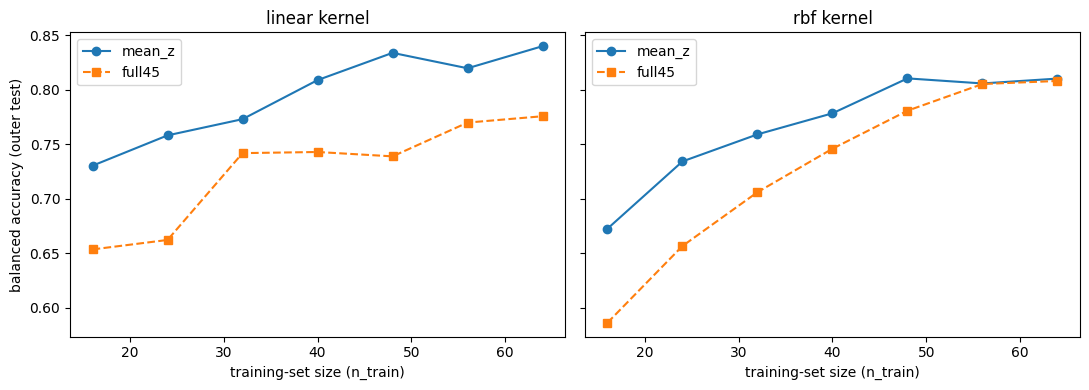

In [ ]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, kn in zip(axes, ['linear', 'rbf']):
        for rep_name, style in [('mean_z', '-o'), ('full45', '--s')]:
            sub = lc_table[(lc_table.representation == rep_name) & (lc_table.model == kn)]
            ax.plot(sub.train_size, sub['mean'], style, label=rep_name)
        ax.set_title(f'{kn} kernel')
        ax.set_xlabel('training-set size (n_train)')
        ax.legend()
    axes[0].set_ylabel('balanced accuracy (outer test)')
    plt.tight_layout()
    plt.savefig(f'{OUTDIR}/exp9_learning_curves.png', dpi=120)
    plt.show()
except ImportError:
    print('matplotlib not available -- see exp9_learning_curves.csv for the numbers')

## 12. Reading these results, and what is still open

**Experiment 1 (composition):** if `comp_freq_20` performs on par with `mean_z`, the
z-scale's numeric content is not adding much beyond raw amino-acid counts. If `mean_z`
wins clearly, the physicochemical values themselves matter.

**Experiment 2 (dimension-matched):** the three-way comparison is the key result. If
`mean_z` beats **both** `rand_proj_5` and `pca_5` by a margin the paired intervals confirm,
dimensionality alone does not explain the pooled representation's strength — the specific
structure of position-averaging does. If either control keeps pace with `mean_z`, the
VC-dimension/bias-variance story regains real support.

**Experiment 3 (anchor positions):** tells you whether whatever positional signal exists
is concentrated at the MHC-I anchor residues specifically, or is absent/diffuse.

**Experiment 4 (residuals, Eq. 3):** the most direct test of `v_p` vs `eps_p`. A residual
term that survives strong regularisation and still improves paired performance is
evidence for real positional signal; one that adds nothing supports composition
dominance.

**Experiment 8 (regression):** an independent, threshold-free confirmation (or
contradiction) of whatever Experiments 1-4 show, using a completely different metric.

**Experiment 9 (learning curves):** read the *trend*, not a single number — does the gap
between `mean_z` and `full45` shrink as training size grows toward 64, or hold steady?

**Deferred:** the selection-aware null test (item 10) — once you've seen which of these
comparisons look interesting, we run the permutation calibration on those specifically,
which is both cheaper and more targeted than calibrating all of them blindly.

**Out of scope here:** composition-preserving redocking (item 7) needs an actual docking
simulator and receptor structure, not a data-analysis notebook.